# Partie 3 - Machine Learning : prediction de l'attrition

Objectif : construire un premier modele de prediction du depart d'un collaborateur, l'evaluer, identifier les variables contributives et discuter ses limites.

Compte tenu de l'environnement disponible, le modele ci-dessous repose sur une **regression logistique codee en Python/Numpy** plutot que sur `scikit-learn`.


In [12]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
df = load_data(DATA_PATH)
pd.set_option("display.max_columns", 100)


## 1. Preparation des donnees

- exclusion de `employee_id`
- imputation simple des valeurs manquantes
- encodage one-hot des variables qualitatives
- standardisation des variables
- split stratifie train / validation / test


In [13]:
prepared = prepare_model_data(df, drop_columns=["employee_id"])

print("Train:", prepared.X_train.shape, prepared.y_train.mean().round(4))
print("Validation:", prepared.X_val.shape, prepared.y_val.mean().round(4))
print("Test:", prepared.X_test.shape, prepared.y_test.mean().round(4))


Train: (4811, 94) 0.0258
Validation: (1604, 94) 0.0262
Test: (1605, 94) 0.0262


## 2. Entrainement du modele

On utilise une regression logistique avec ponderation des classes pour tenir compte du fort desequilibre de la cible.


In [14]:
model = SimpleLogisticRegression(
    learning_rate=0.05,
    epochs=4000,
    reg_strength=0.02,
    class_weight="balanced",
)
model.fit(prepared.X_train, prepared.y_train)

val_scores = model.predict_proba(prepared.X_val)
best_threshold = find_best_threshold(prepared.y_val, val_scores)
best_threshold


{'threshold': np.float64(0.7899999999999999),
 'precision': 0.0847457627118644,
 'recall': 0.11904761904761904,
 'f1_score': 0.09900990099009901,
 'specificity': 0.9654289372599232,
 'accuracy': 0.9432668329177057,
 'tp': 5,
 'tn': 1508,
 'fp': 54,
 'fn': 37}

## 3. Evaluation sur le jeu de test


In [15]:
test_scores = model.predict_proba(prepared.X_test)

metrics = classification_metrics(
    prepared.y_test,
    test_scores,
    threshold=best_threshold["threshold"],
)

evaluation = pd.DataFrame(
    [
        ("ROC-AUC", roc_auc_score_manual(prepared.y_test, test_scores)),
        ("PR-AUC", pr_auc_score_manual(prepared.y_test, test_scores)),
        ("Precision", metrics["precision"]),
        ("Recall", metrics["recall"]),
        ("F1-score", metrics["f1_score"]),
        ("Accuracy", metrics["accuracy"]),
        ("Specificite", metrics["specificity"]),
    ],
    columns=["Metrique", "Valeur"],
)

evaluation["Valeur"] = evaluation["Valeur"].round(4)
evaluation


,Metrique,Valeur
0,ROC-AUC,0.5951
1,PR-AUC,0.0358
2,Precision,0.0244
3,Recall,0.0476
4,F1-score,0.0323
5,Accuracy,0.9252
6,Specificite,0.9488


In [16]:
pd.DataFrame(
    {
        "Mesure": ["TP", "TN", "FP", "FN"],
        "Valeur": [metrics["tp"], metrics["tn"], metrics["fp"], metrics["fn"]],
    }
)


,Mesure,Valeur
0,TP,2
1,TN,1483
2,FP,80
3,FN,40


## 4. Variables importantes

Les coefficients ci-dessous sont interpretes comme des effets directionnels dans le cadre de cette regression logistique standardisee. Ils ne doivent pas etre lus comme des causalites.


In [17]:
importance = coefficient_importance(model, prepared.feature_names, top_n=20)
importance


,feature,coefficient,abs_coefficient,odds_ratio
52,job_role_ML Engineer,-0.7508,0.7508,0.4720
2,contracted_hours_weekly,-0.3628,0.3628,0.6957
8,training_hours,-0.3038,0.3038,0.7380
16,salary,-0.2979,0.2979,0.7424
12,overtime_hours,0.2585,0.2585,1.2950
11,absenteeism_days,0.2563,0.2563,1.2922
15,psychological_safety_score,-0.2535,0.2535,0.7761
49,job_role_Frontend Developer,0.2440,0.2440,1.2764
84,overtime_band_26+,-0.2314,0.2314,0.7934
44,job_role_Data Analyst,0.2234,0.2234,1.2503


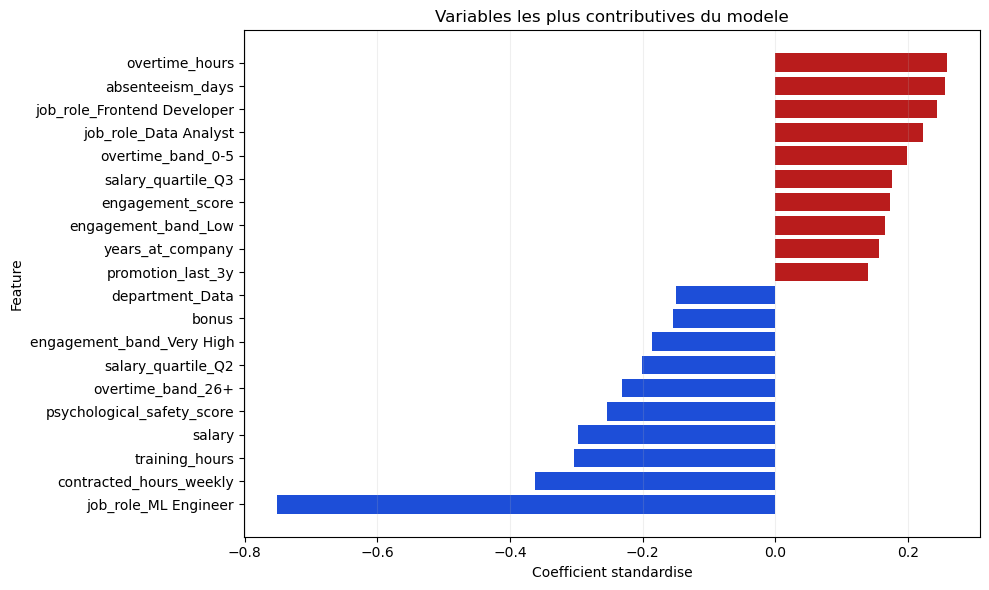

In [18]:
plot_top_coefficients(model, prepared.feature_names, top_n=20)


## 5. Experience d'oversampling

On teste ici un **random oversampling** sur le jeu d'entrainement uniquement. L'objectif n'est pas de "creer de l'information", mais de verifier si une meilleure representation de la classe minoritaire aide le modele a detecter davantage de departs.


In [19]:
oversample = random_oversample_minority(prepared.X_train, prepared.y_train, seed=42)

pd.DataFrame(
    {
        "Jeu": ["Train original", "Train oversample"],
        "Positifs": [oversample.original_positive_count, oversample.resampled_positive_count],
        "Negatifs": [oversample.original_negative_count, oversample.resampled_negative_count],
    }
)


,Jeu,Positifs,Negatifs
0,Train original,124,4687
1,Train oversample,4687,4687


In [20]:
oversampled_model = SimpleLogisticRegression(
    learning_rate=0.05,
    epochs=4000,
    reg_strength=0.02,
    class_weight=None,
)
oversampled_model.fit(oversample.X_resampled, oversample.y_resampled)

oversampled_val_scores = oversampled_model.predict_proba(prepared.X_val)
oversampled_best_threshold = find_best_threshold(prepared.y_val, oversampled_val_scores)
oversampled_test_scores = oversampled_model.predict_proba(prepared.X_test)
oversampled_metrics = classification_metrics(
    prepared.y_test,
    oversampled_test_scores,
    threshold=oversampled_best_threshold["threshold"],
)

comparison = pd.DataFrame(
    [
        (
            "Baseline ponderee",
            roc_auc_score_manual(prepared.y_test, test_scores),
            pr_auc_score_manual(prepared.y_test, test_scores),
            metrics["precision"],
            metrics["recall"],
            metrics["f1_score"],
        ),
        (
            "Random oversampling",
            roc_auc_score_manual(prepared.y_test, oversampled_test_scores),
            pr_auc_score_manual(prepared.y_test, oversampled_test_scores),
            oversampled_metrics["precision"],
            oversampled_metrics["recall"],
            oversampled_metrics["f1_score"],
        ),
    ],
    columns=["Modele", "ROC-AUC", "PR-AUC", "Precision", "Recall", "F1-score"],
).round(4)

comparison


,Modele,ROC-AUC,PR-AUC,Precision,Recall,F1-score
0,Baseline ponderee,0.5951,0.0358,0.0244,0.0476,0.0323
1,Random oversampling,0.5966,0.0358,0.0253,0.0476,0.0331


### Interpretation attendue

- Si le `recall` augmente, l'oversampling aide le modele a rater moins de departs.
- Si la `precision` baisse fortement, cela signifie qu'il produit davantage de faux positifs.
- Si le gain reste faible sur `PR-AUC` et `F1-score`, on peut conclure que le frein principal est la **faiblesse du signal predictif**, plus que le seul desequilibre de classe.


## 6. Experience de detection d'anomalie

Comme l'attrition est rare, on peut aussi tester une logique semi-supervisee : apprendre le profil "normal" des collaborateurs qui restent, puis mesurer a quel point certains profils s'en ecartent.

Ici, on utilise une distance de **Mahalanobis regularisee** sur les variables numeriques, en apprenant le profil de reference uniquement sur les collaborateurs sans attrition du train.


In [21]:
numeric_data = prepare_numeric_anomaly_data(df, drop_columns=["employee_id"])

normal_train = numeric_data.X_train[numeric_data.y_train == 0]
anomaly_model = MahalanobisAnomalyDetector(regularization=0.1)
anomaly_model.fit(normal_train)

anomaly_val_scores = anomaly_model.score_samples(numeric_data.X_val)
anomaly_thresholds = np.quantile(anomaly_val_scores, np.linspace(0.70, 0.99, 60))
anomaly_best_threshold = find_best_threshold(
    numeric_data.y_val,
    anomaly_val_scores,
    thresholds=np.unique(anomaly_thresholds),
)
anomaly_test_scores = anomaly_model.score_samples(numeric_data.X_test)
anomaly_metrics = classification_metrics(
    numeric_data.y_test,
    anomaly_test_scores,
    threshold=anomaly_best_threshold["threshold"],
)

pd.DataFrame(
    [
        ("Anomaly score threshold", anomaly_best_threshold["threshold"]),
        ("ROC-AUC", roc_auc_score_manual(numeric_data.y_test, anomaly_test_scores)),
        ("PR-AUC", pr_auc_score_manual(numeric_data.y_test, anomaly_test_scores)),
        ("Precision", anomaly_metrics["precision"]),
        ("Recall", anomaly_metrics["recall"]),
        ("F1-score", anomaly_metrics["f1_score"]),
    ],
    columns=["Metrique", "Valeur"],
).round(4)


,Metrique,Valeur
0,Anomaly score threshold,4.9142
1,ROC-AUC,0.5463
2,PR-AUC,0.0284
3,Precision,0.0274
4,Recall,0.0952
5,F1-score,0.0426


In [22]:
all_comparison = pd.DataFrame(
    [
        (
            "Baseline ponderee",
            roc_auc_score_manual(prepared.y_test, test_scores),
            pr_auc_score_manual(prepared.y_test, test_scores),
            metrics["precision"],
            metrics["recall"],
            metrics["f1_score"],
        ),
        (
            "Random oversampling",
            roc_auc_score_manual(prepared.y_test, oversampled_test_scores),
            pr_auc_score_manual(prepared.y_test, oversampled_test_scores),
            oversampled_metrics["precision"],
            oversampled_metrics["recall"],
            oversampled_metrics["f1_score"],
        ),
        (
            "Detection d'anomalie",
            roc_auc_score_manual(numeric_data.y_test, anomaly_test_scores),
            pr_auc_score_manual(numeric_data.y_test, anomaly_test_scores),
            anomaly_metrics["precision"],
            anomaly_metrics["recall"],
            anomaly_metrics["f1_score"],
        ),
    ],
    columns=["Approche", "ROC-AUC", "PR-AUC", "Precision", "Recall", "F1-score"],
).round(4)

all_comparison


,Approche,ROC-AUC,PR-AUC,Precision,Recall,F1-score
0,Baseline ponderee,0.5951,0.0358,0.0244,0.0476,0.0323
1,Random oversampling,0.5966,0.0358,0.0253,0.0476,0.0331
2,Detection d'anomalie,0.5463,0.0284,0.0274,0.0952,0.0426


### Lecture critique

- Cette approche est interessante quand la classe positive est rare, car elle ne suppose pas de bien "apprendre" beaucoup de cas de depart.
- En revanche, elle repose sur une hypothese forte : les departs seraient des profils **atypiques** par rapport aux collaborateurs qui restent.
- Si les collaborateurs qui quittent l'entreprise ne sont pas des anomalies nettes mais des cas proches du reste de la population, la methode restera limitee.


## 7. Lecture business du modele

Variables associees a un **risque plus eleve** dans cette version du modele :

- anciennete (`years_at_company`) dans certaines configurations
- roles ou pays specifiques comme la France
- absentisme plus eleve

Variables associees a un **risque plus faible** :

- plus d'heures de formation
- meilleure securite psychologique
- salaire plus eleve
- un temps contractuel plus important
- davantage de teletravail dans ce dataset


## 8. Analyse critique

### Ce que le modele apporte

- un premier cadre de priorisation des populations a surveiller
- une lecture interpretable grace aux coefficients
- une base solide pour une future industrialisation

### Limites majeures

- la cible est **tres desequilibree** (2,59 % de departs)
- les performances restent **modestes** : le modele detecte un signal faible
- l'oversampling peut ameliorer la detection de la classe minoritaire, mais il ne compense pas l'absence de variables fortement explicatives
- la detection d'anomalie est pertinente comme comparaison, mais elle n'est utile que si les departs se comportent vraiment comme des cas atypiques
- plusieurs variables sont potentiellement sensibles ou discutables d'un point de vue ethique (`gender`, `accented_name_flag`)
- les donnees semblent relativement peu structurees autour d'un signal fort d'attrition, ce qui limite la precision operationnelle

### Conclusion

Le modele est utile comme **outil d'exploration et d'alerte faible**, mais insuffisant a ce stade pour piloter seul des decisions RH individuelles.
